## 10. Κανονικές Εκφράσεις

<!-- book-intro-cell -->
### Εισαγωγή από το βιβλίο

Κατά τη διαδικασία εξαγωγής πληροφορίας από τον Ιστό, συχνά βρισκόμαστε αντιμέτωποι με δεδομένα που, αν και εντοπίζονται σωστά μέσα στην HTML, δεν είναι άμεσα αξιοποιήσιμα. Μια τιμή μπορεί να συνοδεύεται από σύμβολα, ένα URL να περιέχει περιττές παραμέτρους ή ένα κείμενο να περιλαμβάνει θόρυβο και ασυνέπειες μορφοποίησης. Σε αυτό το σημείο, η ανάλυση της δομής του HTML αρχείου δεν επαρκεί. Χρειαζόμαστε έναν τρόπο να περιγράψουμε και να εντοπίσουμε πρότυπα μέσα σε κείμενο.

Οι κανονικές εκφράσεις (regular expressions ή regex) αποτελούν ένα ισχυρό εργαλείο για αυτόν ακριβώς τον σκοπό. Μας επιτρέπουν να ορίσουμε κανόνες αναζήτησης που δεν βασίζονται σε συγκεκριμένες λέξεις, αλλά σε γενικές μορφές, όπως ακολουθίες αριθμών, λέξεις που ξεκινούν με κεφαλαίο ή συμβολοσειρές που μοιάζουν με URLs. Στο υποκεφάλαιο αυτό θα δούμε πώς μπορούμε να χρησιμοποιήσουμε κανονικές εκφράσεις για αναγνώριση προτύπων μέσα σε κείμενο, καθαρισμό δεδομένων που προέρχονται από scraping, και συνδυασμό τους με εργαλεία όπως η βιβλιοθήκη BeautifulSoup.


In [ ]:
import re

In [ ]:
re.findall(r"\d+", "Price: 999 euros")

['999']

#### Επανάληψη

In [ ]:
re.findall(r"\d+", "NaN A1 B22 C333")

['1', '22', '333']

In [ ]:
re.findall(r"\d{3}", "NaN A1 B22 C333")

['333']

In [ ]:
re.findall(r"\d{2,3}", "NaN A1 B22 C333")

['22', '333']

#### Ομαδοποίηση και Εναλλακτικές

In [ ]:
re.findall(r"(abc)", "abc xyz abc")

['abc', 'abc']

In [ ]:
re.findall(r"(ab)+", "ab abab ababab")

['ab', 'ab', 'ab']

In [ ]:
re.findall(r"(cat|dog)", "cat dog bird cat")

['cat', 'dog', 'cat']

In [ ]:
re.findall(r"(Mr|Ms)\.?\s[A-Z][a-z]+", "Mr Smith Ms Johnson")

['Mr', 'Ms']

#### Αρχή και τέλος

In [ ]:
re.findall(r"^\d+", "123abc")

['123']

In [ ]:
re.findall(r"^\d+", "abc123")

[]

In [ ]:
re.findall(r"(cat|dog)", "cat dog bird")

['cat', 'dog']

#### Άπληστη αναζήτηση

In [ ]:
re.findall(r"<.*>", "<tag>text</tag>")

['<tag>text</tag>']

In [ ]:
re.findall(r"<.*?>", "<tag>text</tag>")

['<tag>', '</tag>']

In [ ]:
text = "<div>first</div><div>second</div>"

matches = re.findall(r"<div>.*</div>", text)
print(matches)

['<div>first</div><div>second</div>']


In [ ]:
text = "<p>Τιμή: €999</p><p>Τιμή: €799</p>"

In [ ]:
re.findall(r"<p>.*</p>", text)

['<p>Τιμή: €999</p><p>Τιμή: €799</p>']

In [ ]:
re.findall(r"<p>.*?</p>", text)

['<p>Τιμή: €999</p>', '<p>Τιμή: €799</p>']

#### Raw strings

In [ ]:
import re

pattern = "\d+"
print(pattern)

\d+


<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_23715/3076329716.py:3: SyntaxWarning: invalid escape sequence '\d'
  pattern = "\d+"


In [ ]:
pattern = "\n\d+"
print(pattern)


\d+


<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_23715/2156298723.py:1: SyntaxWarning: invalid escape sequence '\d'
  pattern = "\n\d+"


In [ ]:
print(r"\d+")

\d+


In [ ]:
print(r"\n\d+")

\n\d+


In [ ]:
text = "Price:\n999"
re.findall(r"\n\d+", text)

['\n999']

#### Κλάση χαρακτήρα

In [ ]:
re.findall(r"[a-z]+", "Data Science 101")

['ata', 'cience']

In [ ]:
re.findall(r"[a-zA-Z]+", "AI2025 is evolving")

['AI', 'is', 'evolving']

In [ ]:
re.findall(r"[^0-9]+", "abc123xyz")

['abc', 'xyz']

In [ ]:
re.findall(r"[.+*]", "a+b*c.")

['+', '*', '.']

#### 10.7 Εφαρμογή: Εξαγωγή χρονοσειράς πληθυσμού

In [ ]:
import requests
import re

url = "https://www.worldometers.info/world-population/greece-population/"
headers = {'User-Agent': 'Mozilla/5.0'}

def robust_scrape():
    response = requests.get(url, headers=headers)
    html = response.text

    # Νέο Pattern βασισμένο στο κείμενο "estimated at"
    # Ψάχνουμε: estimated at <span ...><span> ΑΡΙΘΜΟΣ </span></span>
    pop_pattern = r'estimated at <span.*?><span>([\d,]+)</span></span>'

    # Pattern για τη Διάμεση Ηλικία (Median Age)
    age_pattern = r'median age in Greece is <span.*?><span>(.*?) years</span>'

    pop_result = re.findall(pop_pattern, html)
    age_result = re.findall(age_pattern, html)

    if pop_result:
        population = int(pop_result[0].replace(',', ''))
        print(f"Πληθυσμός 2026: {population:,}")

    if age_result:
        median_age = float(age_result[0])
        print(f"Διάμεση Ηλικία: {median_age} έτη")

robust_scrape()

Πληθυσμός 2026: 9,897,115


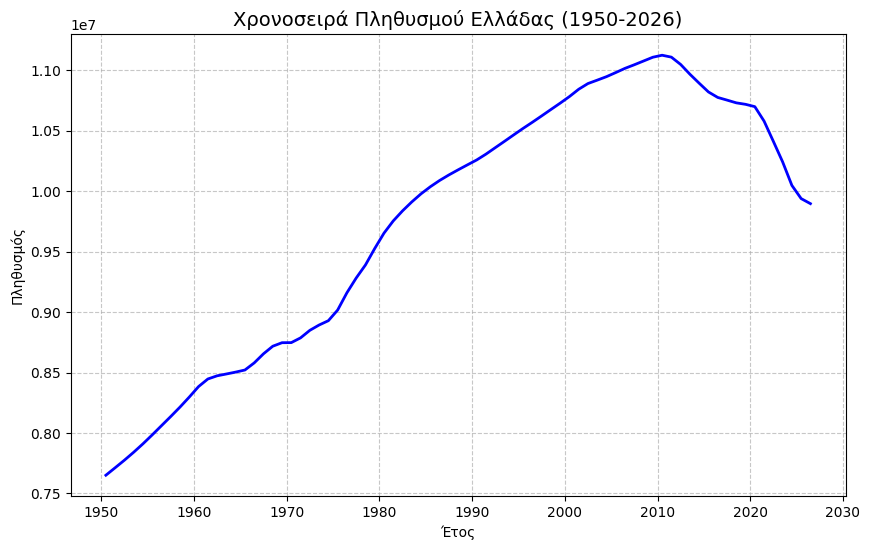

                           Population
Date                                 
2022-06-30 22:00:00+00:00    10412480
2023-06-30 21:00:00+00:00    10242908
2024-06-30 21:00:00+00:00    10047817
2025-06-30 21:00:00+00:00     9938844
2026-06-30 21:00:00+00:00     9897115


In [ ]:
import requests
import re
import json
import pandas as pd
import matplotlib.pyplot as plt

# 1. Λήψη δεδομένων
url = "https://www.worldometers.info/world-population/greece-population/"
headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(url, headers=headers)
html = response.text

# 2. Regex για την εξαγωγή του data-rows από το google-chart tag
# Ψάχνουμε το περιεχόμενο μέσα στα data-rows="..."
pattern = r'data-rows="([^"]+)"'
matches = re.findall(pattern, html)

if matches:
    # Το Worldometers κωδικοποιεί τα εισαγωγικά ως &#34;
    # Πρέπει να τα επαναφέρουμε για να το διαβάσει η json.loads
    raw_json = matches[0].replace('&#34;', '"')
    data_list = json.loads(raw_json)

    # 3. Δημιουργία DataFrame
    # Η λίστα έχει μορφή: [["2026-06-30...", 9897115], ...]
    df = pd.DataFrame(data_list, columns=['Date', 'Population'])

    # 4. Μετατροπή σε Χρονοσειρά (Time Series Processing)
    df['Date'] = pd.to_datetime(df['Date']) # Μετατροπή σε ημερομηνία
    df.set_index('Date', inplace=True)      # Ορισμός της ημερομηνίας ως Index
    df.sort_index(inplace=True)             # Ταξινόμηση από το παλιό στο νέο

    # 5. Οπτικοποίηση
    plt.figure(figsize=(10, 6))
    plt.plot(df.index, df['Population'], color='blue', linewidth=2)
    plt.title('Χρονοσειρά Πληθυσμού Ελλάδας (1950-2026)', fontsize=14)
    plt.xlabel('Έτος')
    plt.ylabel('Πληθυσμός')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    # Bonus: Εμφάνιση των τελευταίων ετών
    print(df.tail())

[('01', '05', '2024')]


### 10.8 Εφαρμογή: Εξαγωγή πληροφορίας από τη Διαύγεια

In [ ]:
import requests

# Αναζήτηση αποφάσεων που αφορούν "πληροφορική"
api_url = "https://diavgeia.gov.gr/opendata/search.json?q=πληροφορική"
response = requests.get(api_url)
data = response.json()
decisions = data['decisions']
print(f"Θέμα απόφασης: {decisions[0]['subject']}")

Θέμα απόφασης: ΚΛΑΔΕΜΑΤΑ ΜΕΓΑΛΩΝ ΔΕΝΤΡΩΝ ΛΟΓΩ ΕΠΙΚΙΝΔΥΝΟΤΗΤΑΣ ΣΤΗ Δ.Ε. ΛΙΑΝΟΚΛΑΔΙΟΥ


In [ ]:
data['info']

{'query': 'submissionTimestamp:[DT(2025-10-18T09:14:05+03:00) TO DT(2026-04-16T09:14:05+03:00)] AND issueDate:[DT(2025-10-18T09:14:05+03:00) TO DT(2026-04-16T09:14:05+03:00)] AND status:"Αναρτημένη"',
 'page': 2,
 'size': 100,
 'actualSize': 100,
 'total': 3202545,
 'order': 'recent'}

In [ ]:
import requests

api_url = "https://diavgeia.gov.gr/opendata/search.json"
params = {
    "q": "πληροφορική",
    "size": 500,
    "page": 0,
    "order": "recent"
}

response = requests.get(api_url, params=params)
data = response.json()

print(f"Επέστρεψαν {len(data['decisions'])} αποτελέσματα.")

Επέστρεψαν 500 αποτελέσματα.


In [ ]:
from tqdm.notebook import tqdm

all_data = []
for i in tqdm(range(10)):
  params = {
    "q": "πληροφορική",
    "size": 500,
    "page": i,
    "order": "recent"
  }
  results = requests.get(api_url, params=params).json()
  all_data.extend(results['decisions'])

len(all_data)

  0%|          | 0/10 [00:00<?, ?it/s]

5000

In [ ]:
all_data[0]

{'protocolNumber': 'Δ764',
 'subject': 'ΠΑΡΑΓΩΓΗ ΒΙΒΛΙΟΥ',
 'issueDate': 1776297600000,
 'organizationId': '99221065',
 'signerIds': ['135953'],
 'unitIds': ['72478'],
 'decisionTypeId': 'Δ.1',
 'thematicCategoryIds': ['32'],
 'extraFieldValues': {'person': [{'afm': '999754258',
    'name': 'PAPER GRAPH ΓΡΑΦΙΚΕΣ ΤΕΧΝΕΣ ΑΝΩΝΥΜΗ ΕΤΑΙΡΕΙΑ',
    'enterName': False,
    'afmType': 'EL'}],
  'awardAmount': {'amount': 7292.8, 'currency': 'EUR'},
  'assignmentType': 'Προμήθειες',
  'cpv': None,
  'textRelatedADA': None,
  'relatedDecisions': [],
  'documentType': 'ΠΡΑΞΗ'},
 'privateData': False,
 'ada': 'Ψ8ΡΡ469ΗΚΥ-ΞΚ8',
 'publishTimestamp': 1776327149364,
 'submissionTimestamp': 1776327149364,
 'versionId': 'ef010927-7259-46bd-aaaf-7c19c7821a8d',
 'status': 'PUBLISHED',
 'url': 'https://diavgeia.gov.gr/luminapi/api/decisions/Ψ8ΡΡ469ΗΚΥ-ΞΚ8',
 'documentUrl': 'https://diavgeia.gov.gr/doc/Ψ8ΡΡ469ΗΚΥ-ΞΚ8',
 'documentChecksum': None,
 'attachments': [],
 'warnings': None,
 'correctedVersionId': No

In [ ]:
import pandas as pd
import re

df = pd.DataFrame(all_data)

# 1. Επεξεργασία Χρόνου (Time Analysis)
# Μετατροπή των Unix ms Timestamps σε αντικείμενα Datetime
df['issue_dt'] = pd.to_datetime(df['issueDate'], unit='ms')
df['submit_dt'] = pd.to_datetime(df['submissionTimestamp'], unit='ms')

# Υπολογισμός της καθυστέρησης σε ημέρες
df['delay_days'] = (df['submit_dt'] - df['issue_dt']).dt.days

# 2. Χρήση RegEx για Κατηγοριοποίηση (Feature Engineering)
def classify_subject(subject):
    # Ορίζουμε μοτίβα για τις πιο συχνές δαπάνες
    categories = {
        'Μεταφορές/Καύσιμα': r'ΚΑΥΣΙΜ|ΜΕΤΑΦΟΡ|ΟΔΟΙΠΟΡ',
        'Υποδομές/Επισκευές': r'ΕΠΙΣΚΕΥ|ΣΥΝΤΗΡΗΣ|ΚΤΙΡ',
        'Πληροφορική': r'ΠΛΗΡΟΦΟΡ|ΛΟΓΙΣΜΙΚ|INTERNET',
        'Μισθοδοσία': r'ΜΙΣΘΟΔ|ΑΠΟΖΗΜΙΩΣ'
    }

    for cat, pattern in categories.items():
        if re.search(pattern, subject, re.IGNORECASE):
            return cat
    return 'Άλλο'

# Εφαρμογή του RegEx στη στήλη subject
df['Category'] = df['subject'].apply(classify_subject)

# 3. Τελική Ανάλυση: Μέση καθυστέρηση ανά κατηγορία δαπάνης
analysis = df.groupby('Category')['delay_days'].mean()
print("Μέση καθυστέρηση (ημέρες) ανά κατηγορία:")
print(analysis)

Μέση καθυστέρηση (ημέρες) ανά κατηγορία:
Category
Άλλο                   4.020999
Μεταφορές/Καύσιμα      5.248120
Μισθοδοσία            11.444444
Πληροφορική            9.700000
Υποδομές/Επισκευές     2.081218
Name: delay_days, dtype: float64


In [ ]:
df.sample()

,protocolNumber,subject,issueDate,organizationId,signerIds,unitIds,decisionTypeId,thematicCategoryIds,extraFieldValues,privateData,...,url,documentUrl,documentChecksum,attachments,warnings,correctedVersionId,issue_dt,submit_dt,delay_days,Category
1462,5969,Επίβλεψη της υπ'αριθμό Ο.Α. 360760/14-02-2022 ...,1776297600000,6186,[100084856],[84722],Β.1.3,[20],"{'financialYear': 2026, 'budgettype': 'Τακτικό...",False,...,https://diavgeia.gov.gr/luminapi/api/decisions...,https://diavgeia.gov.gr/doc/6ΣΟΙΩΛ8-7ΛΠ,None,[],None,None,2026-04-16,2026-04-16 07:45:30.232,0,Άλλο


/tmp/ipykernel_23715/3917206955.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(


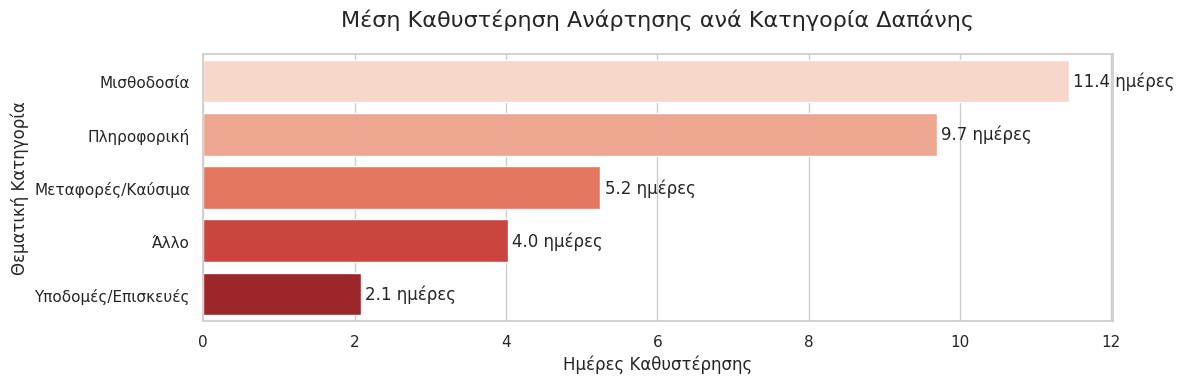

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 4))

order = df.groupby('Category')['delay_days'].mean().sort_values(ascending=False).index
plot = sns.barplot(
    data=df,
    x='delay_days',
    y='Category',
    legend=False,
    order=order,
    palette='Reds',
    errorbar=None
)

plt.title('Μέση Καθυστέρηση Ανάρτησης ανά Κατηγορία Δαπάνης', fontsize=16, pad=20)
plt.xlabel('Ημέρες Καθυστέρησης', fontsize=12)
plt.ylabel('Θεματική Κατηγορία', fontsize=12)

for i in plot.containers: plot.bar_label(i, padding=3, fmt='%.1f ημέρες')

plt.tight_layout()
plt.show()